Import libraries

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import joblib

Load dataset and load basic info

In [40]:
#Display all the columns of t he dataframe
pd.pandas.set_option('display.max_columns',None)


#Load dataset
df=pd.read_csv("hairstyle_prediction_dataset_1000.csv")

#print the shape of the dataset with rows and columns
print("Shape of the dataset: ",df.shape)

#top 5 records
df.head()


Shape of the dataset:  (1000, 6)


,face_width,jaw_width,forehead_width,chin_length,face_shape,best_hairstyle
0,145,124,134,47,heart,chin_length_bob
1,149,122,131,49,heart,chin_length_bob
2,139,131,130,43,round,layered_bob
3,154,130,148,46,oval,straight_cut
4,155,143,146,57,oblong,fringe_bangs


Missing values

In [41]:
df.isna().sum()

face_width        0
jaw_width         0
forehead_width    0
chin_length       0
face_shape        0
best_hairstyle    0
dtype: int64

Numerical variables

In [42]:
numeric_df = df.select_dtypes(include=['number'])

numeric_df.head()

,face_width,jaw_width,forehead_width,chin_length
0,145,124,134,47
1,149,122,131,49
2,139,131,130,43
3,154,130,148,46
4,155,143,146,57


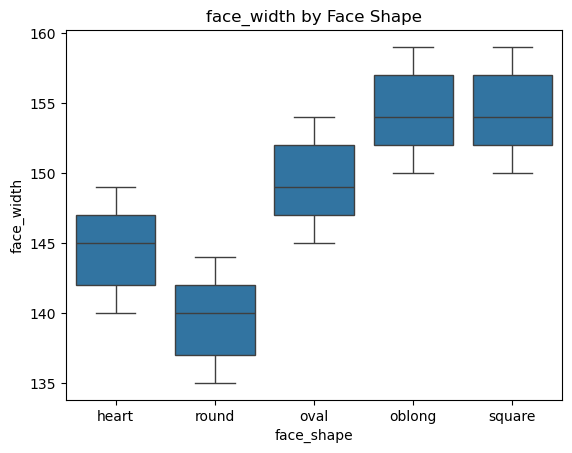

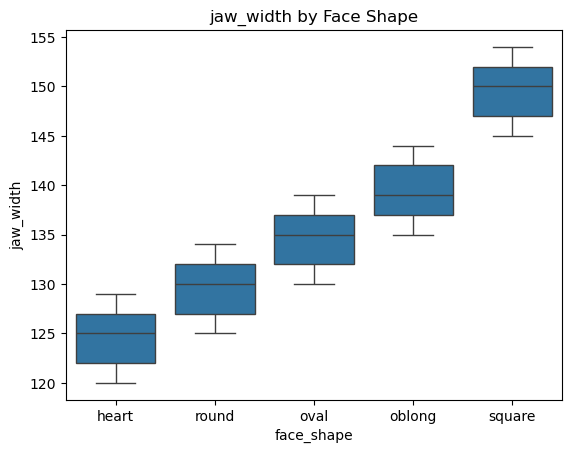

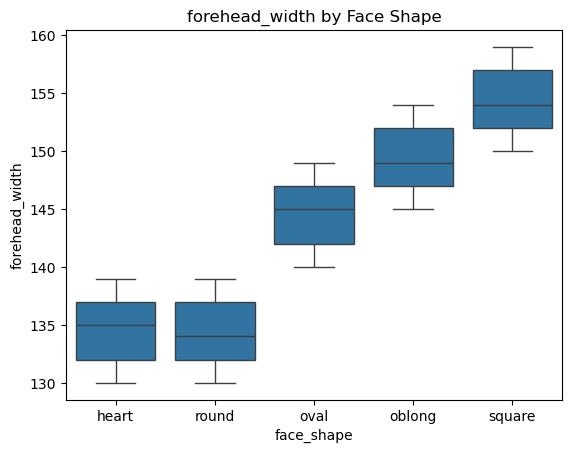

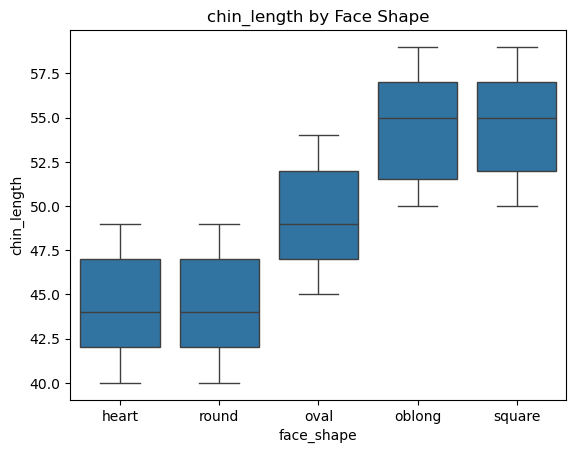

In [43]:
#shows how each numerical feature varies by face shape

for col in numeric_df.columns:
    sns.boxplot(x='face_shape', y=col, data=df)
    plt.title(f'{col} by Face Shape')
    plt.show()

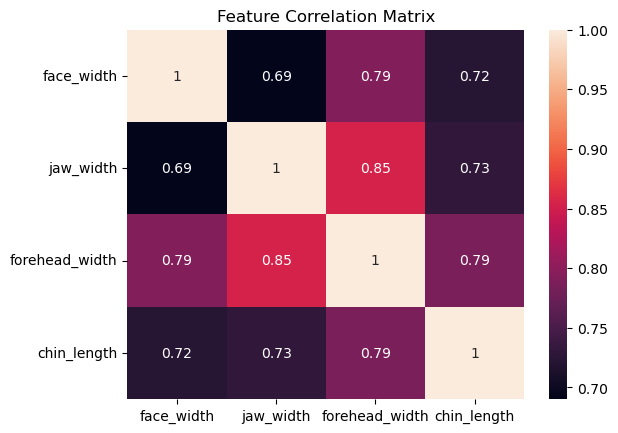

In [44]:
#Understand relationships between numerical features
corr = numeric_df.corr()
sns.heatmap(corr, annot=True)
plt.title("Feature Correlation Matrix")
plt.show()

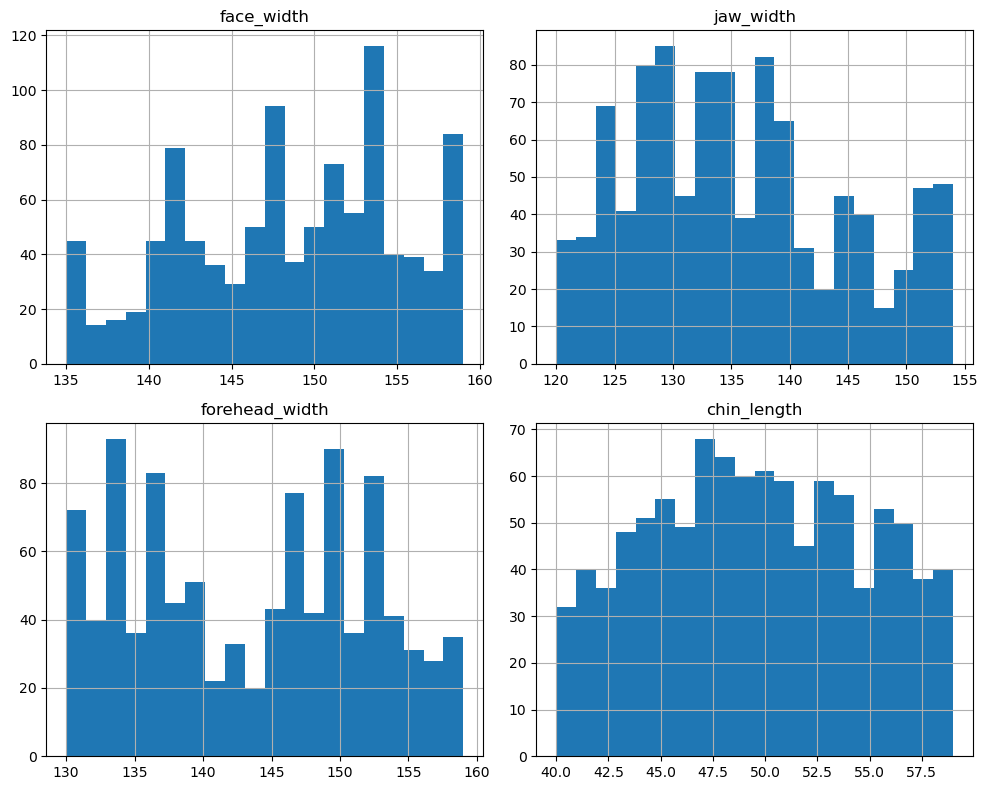

In [45]:
#Shows distribution shape (normal, skewed, bimodal)
# to decide whether scaling, transformation, or outlier handling is needed.
numeric_df.hist(bins=20, figsize=(10, 8))
plt.tight_layout()
plt.show()


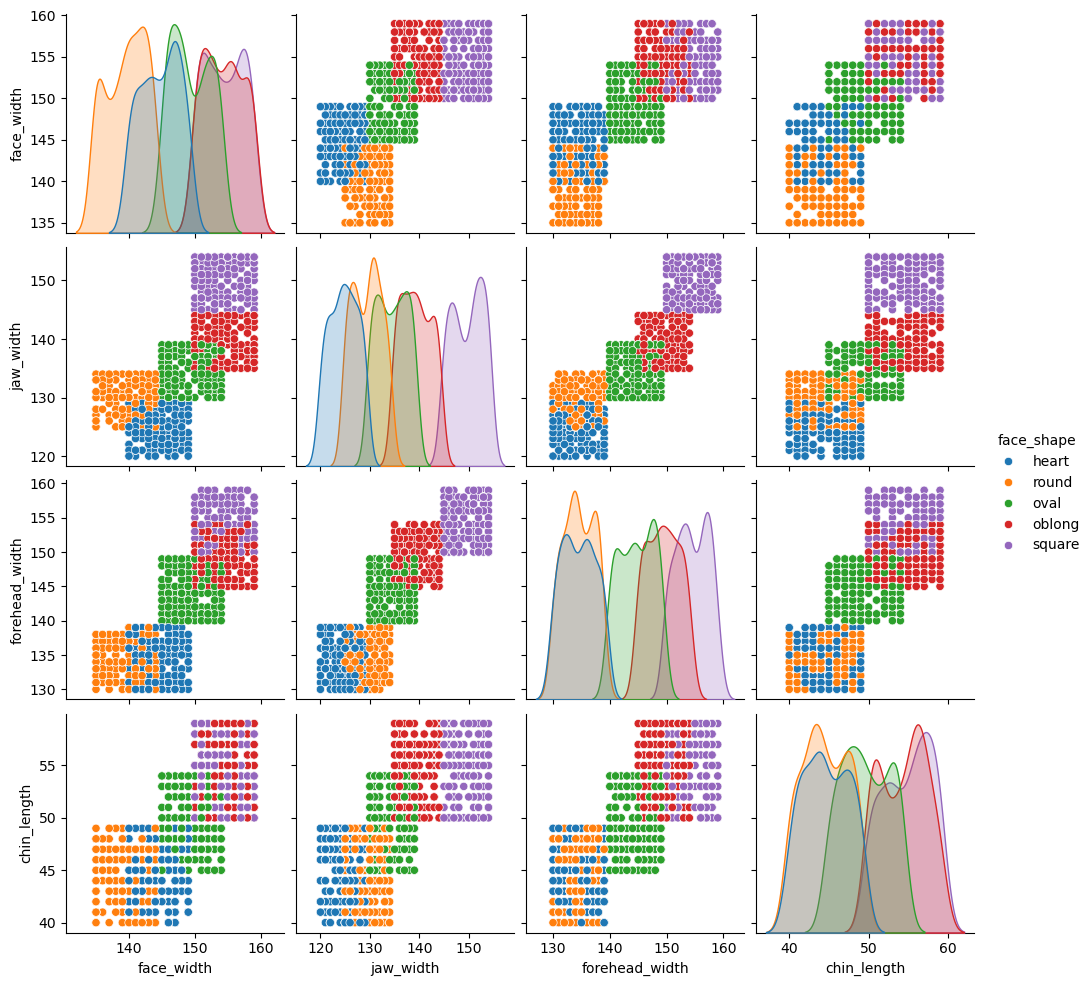

In [46]:
#Visualize pairwise relationships by class
#To decide feature separability, which helps in model choice

sns.pairplot(df, vars=numeric_df.columns, hue='face_shape')
plt.show()


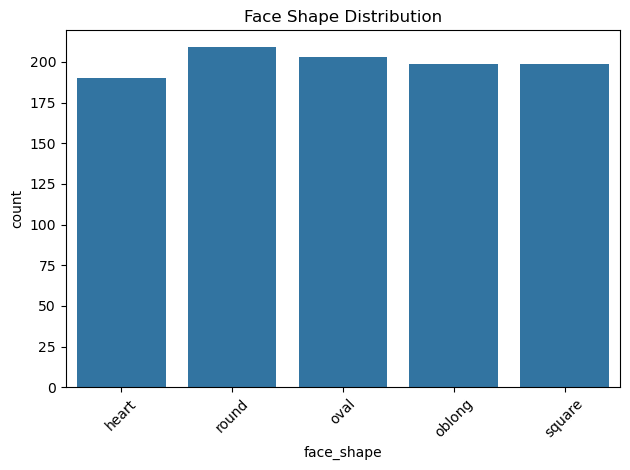

In [47]:
#count of each face shape
# #k-NN can be biased toward majority classes if class imbalance exists. This plot helps verify balance.

sns.countplot(x='face_shape', data=df)
plt.title('Face Shape Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
